## Project Introduction

Rusty Bargain, a used car sales service, is developing a mobile application to attract new customers by allowing them to quickly determine the market value of their vehicles. The app leverages historical data containing vehicle technical specifications, trim versions, and prices to power its pricing model.  

The goal of this project is to build a predictive model that accurately estimates a car’s market value while maintaining high performance in terms of both prediction speed and training time. Rusty Bargain’s key priorities are:  

1. **Prediction Quality** – Achieving low error rates for price estimation.  
2. **Prediction Speed** – Ensuring quick response times for user queries.  
3. **Training Time** – Optimizing model training to balance efficiency and accuracy.  

The provided dataset contains various features such as vehicle type, registration year, gearbox type, power, mileage, fuel type, brand, repair status, and other metadata. The target variable is the vehicle’s price in Euros.  

In this project, multiple modeling approaches will be explored and compared, including:  
- **Linear Regression** (sanity check)  
- **Tree-Based Models** (Decision Tree, Random Forest) with hyperparameter tuning  
- **Gradient Boosting Methods** (LightGBM with tuning, plus optional CatBoost and XGBoost)  

Model evaluation will focus on the **Root Mean Squared Error (RMSE)** metric, alongside training time and prediction latency. The results will guide the selection of the most effective model for integration into Rusty Bargain’s application, ensuring users receive fast and accurate car value estimates.


## Environment Setup and Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split, cross_val_score
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, r2_score, make_scorer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from scipy import stats as st
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
import time
from scipy.stats import randint


## Step 1: Loading and Initial Data Exploration

In [2]:
df = pd.read_csv('/datasets/car_data.csv')
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [4]:
df.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [5]:
df.duplicated().sum()

262

In [6]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
87112,01/04/2016 05:02,6199,coupe,1999,manual,193,3er,150000,5,petrol,bmw,no,01/04/2016 00:00,0,99974,07/04/2016 06:15
90786,01/04/2016 05:02,6199,coupe,1999,manual,193,3er,150000,5,petrol,bmw,no,01/04/2016 00:00,0,99974,07/04/2016 06:15
45825,01/04/2016 10:38,3499,small,2005,manual,86,getz,50000,5,petrol,hyundai,no,01/04/2016 00:00,0,47800,07/04/2016 06:46
142496,01/04/2016 10:38,3499,small,2005,manual,86,getz,50000,5,petrol,hyundai,no,01/04/2016 00:00,0,47800,07/04/2016 06:46
12578,01/04/2016 12:57,1499,wagon,1995,manual,150,5er,150000,6,petrol,bmw,no,01/04/2016 00:00,0,25821,07/04/2016 09:44


In [7]:
df.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Mileage                  0
RegistrationMonth        0
FuelType             32895
Brand                    0
NotRepaired          71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

In [8]:
missing_percentage = ((df.isna().sum() / len(df)) * 100).round(2)
missing_percentage

DateCrawled           0.00
Price                 0.00
VehicleType          10.58
RegistrationYear      0.00
Gearbox               5.60
Power                 0.00
Model                 5.56
Mileage               0.00
RegistrationMonth     0.00
FuelType              9.28
Brand                 0.00
NotRepaired          20.08
DateCreated           0.00
NumberOfPictures      0.00
PostalCode            0.00
LastSeen              0.00
dtype: float64

### Findings

#### Things to fix
- Columns into standardized naming conventions.
- Handled Missing Values
- Convert date fields to datetime64[ns]: date_crawled, date_created, last_seen
- Convert categorical fields to category: vehicle_type, gearbox, model, fuel_type, brand, not_repaired, postal_code
- Improve memory efficiency and ensured proper handling of categorical data during modeling.
#### Feature Cleanup

Drop the number_of_pictures column, as it contained no informative variance (constant values).

### Fill nulls 
in the following features with placeholder values ('unknown') or most common non-null:

- vehicle_type (37,490 missing) 10.58%
- gearbox (19,833 missing)  5.60%
- model (19,705 missing) 5.56%
- fuel_type (32,895 missing) 9.28%
- not_repaired (71,154 missing) 20.08%








## Data preparation

In [9]:
df.columns = df.columns.str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True).str.lower()
df.head(1)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16


In [10]:
df.dtypes

date_crawled          object
price                  int64
vehicle_type          object
registration_year      int64
gearbox               object
power                  int64
model                 object
mileage                int64
registration_month     int64
fuel_type             object
brand                 object
not_repaired          object
date_created          object
number_of_pictures     int64
postal_code            int64
last_seen             object
dtype: object

In [11]:
df['date_crawled'] = pd.to_datetime(df['date_crawled'], errors='coerce')
df['date_created'] = pd.to_datetime(df['date_created'], errors='coerce')
df['last_seen'] = pd.to_datetime(df['last_seen'], errors='coerce')

### FILL NULLS

In [12]:
df['not_repaired'] = df['not_repaired'].fillna('unknown')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354369 non-null  datetime64[ns]
 1   price               354369 non-null  int64         
 2   vehicle_type        316879 non-null  object        
 3   registration_year   354369 non-null  int64         
 4   gearbox             334536 non-null  object        
 5   power               354369 non-null  int64         
 6   model               334664 non-null  object        
 7   mileage             354369 non-null  int64         
 8   registration_month  354369 non-null  int64         
 9   fuel_type           321474 non-null  object        
 10  brand               354369 non-null  object        
 11  not_repaired        354369 non-null  object        
 12  date_created        354369 non-null  datetime64[ns]
 13  number_of_pictures  354369 no

In [13]:
brand_to_model = (
    df[df['model'].notna()]
    .groupby('brand')['model']
    .agg(lambda x: x.value_counts().idxmax())  # most common non-null category per brand
)

df['model'] = df['model'].fillna(
    df['brand'].map(brand_to_model)
)
df['model'].isna().sum()



3374

In [14]:
df.head()

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:00,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,unknown,2016-03-24,0,70435,2016-07-04 03:16:00
1,2016-03-24 10:58:00,18300,coupe,2011,manual,190,a4,125000,5,gasoline,audi,yes,2016-03-24,0,66954,2016-07-04 01:46:00
2,2016-03-14 12:52:00,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,unknown,2016-03-14,0,90480,2016-05-04 12:47:00
3,2016-03-17 16:54:00,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:00
4,2016-03-31 17:25:00,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,2016-06-04 10:17:00


In [15]:
model_to_veh = (
    df[df['vehicle_type'].notna()]
    .groupby('model')['vehicle_type']
    .agg(lambda x: x.value_counts().idxmax())  # most common non-null category per model
)

df['vehicle_type'] = df['vehicle_type'].fillna(
    df['model'].map(model_to_veh)
)
df['vehicle_type'].isna().sum()



1041

In [16]:
model_to_gears = (
    df[df['gearbox'].notna()]
    .groupby('model')['gearbox']
    .agg(lambda x: x.value_counts().idxmax())  # most common non-null category per model
)

df['gearbox'] = df['gearbox'].fillna(
    df['model'].map(model_to_gears)
)
df['gearbox'].isna().sum()

1103

In [17]:
model_to_fuel = (
    df[df['fuel_type'].notna()]
    .groupby('model')['fuel_type']
    .agg(lambda x: x.value_counts().idxmax())  # most common non-null category per model
)

df['fuel_type'] = df['fuel_type'].fillna(
    df['model'].map(model_to_fuel)
)
df['fuel_type'].isna().sum()

1104

In [18]:
df.isna().sum()

date_crawled             0
price                    0
vehicle_type          1041
registration_year        0
gearbox               1103
power                    0
model                 3374
mileage                  0
registration_month       0
fuel_type             1104
brand                    0
not_repaired             0
date_created             0
number_of_pictures       0
postal_code              0
last_seen                0
dtype: int64

In [19]:
df = df.fillna('unknown')

In [20]:
df = df.drop('number_of_pictures', axis=1)

In [21]:

cat_cols = ['vehicle_type', 'gearbox', 'model', 'fuel_type', 'brand', 'not_repaired', 'postal_code']
df[cat_cols] = df[cat_cols].astype('category')

In [22]:
df = df.drop_duplicates().reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354096 entries, 0 to 354095
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354096 non-null  datetime64[ns]
 1   price               354096 non-null  int64         
 2   vehicle_type        354096 non-null  category      
 3   registration_year   354096 non-null  int64         
 4   gearbox             354096 non-null  category      
 5   power               354096 non-null  int64         
 6   model               354096 non-null  category      
 7   mileage             354096 non-null  int64         
 8   registration_month  354096 non-null  int64         
 9   fuel_type           354096 non-null  category      
 10  brand               354096 non-null  category      
 11  not_repaired        354096 non-null  category      
 12  date_created        354096 non-null  datetime64[ns]
 13  postal_code         354096 no

### Summary
#### Data Preprocessing Summary  

- **Handled Missing Values**  
  Filled nulls in the following categorical features with placeholder values (`'unknown'`) or most common non-null:  
  - `vehicle_type` (37,490 missing)  
  - `gearbox` (19,833 missing)  
  - `model` (19,705 missing)  
  - `fuel_type` (32,895 missing)  
  - `not_repaired` (71,154 missing)  

- **Converted Data Types**  
  - Converted date fields to `datetime64[ns]`: `date_crawled`, `date_created`, `last_seen`  
  - Converted categorical fields to `category`: `vehicle_type`, `gearbox`, `model`, `fuel_type`, `brand`, `not_repaired`, `postal_code`  
  - Improved memory efficiency and ensured proper handling of categorical data during modeling.  

- **Feature Cleanup**  
  - Dropped the `number_of_pictures` column, as it contained no informative variance (constant values).  


## EDA 

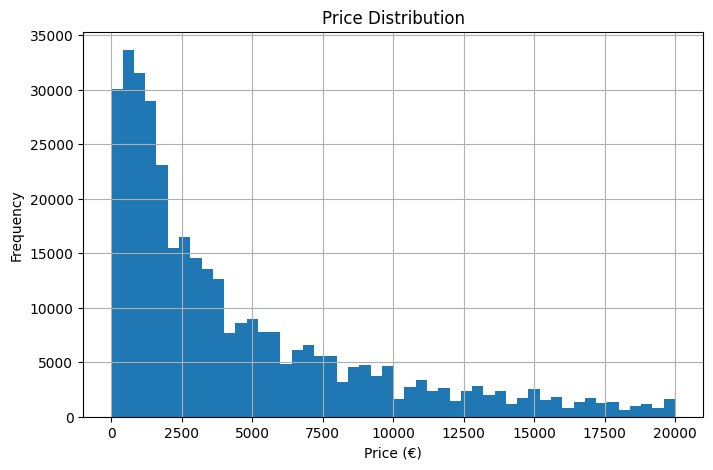

In [23]:
df['price'].hist(bins=50, figsize=(8,5))
plt.title("Price Distribution")
plt.xlabel("Price (€)")
plt.ylabel("Frequency")
plt.show()



<AxesSubplot:xlabel='price'>

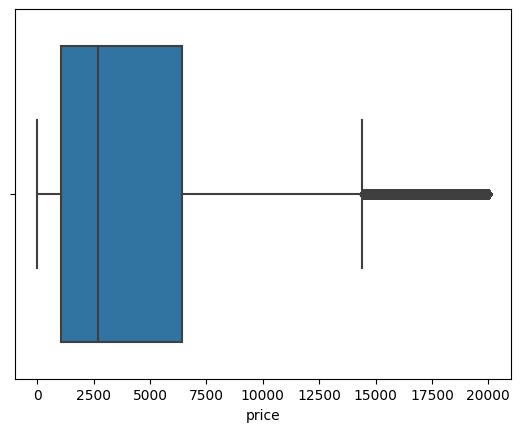

In [24]:
sns.boxplot(x=df['price'])


<AxesSubplot:>

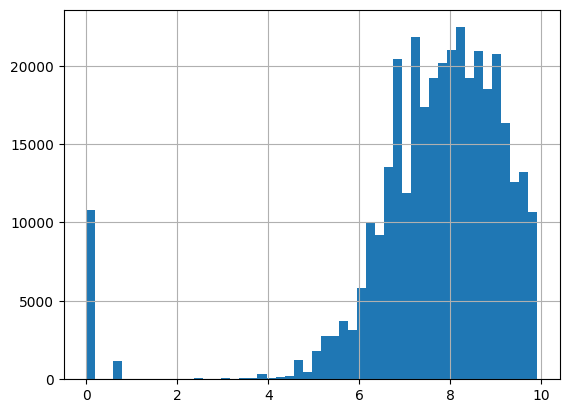

In [25]:
df['price'].apply(lambda x: np.log1p(x)).hist(bins=50)


Text(0.5, 1.0, 'Distribution of Vehicle Types')

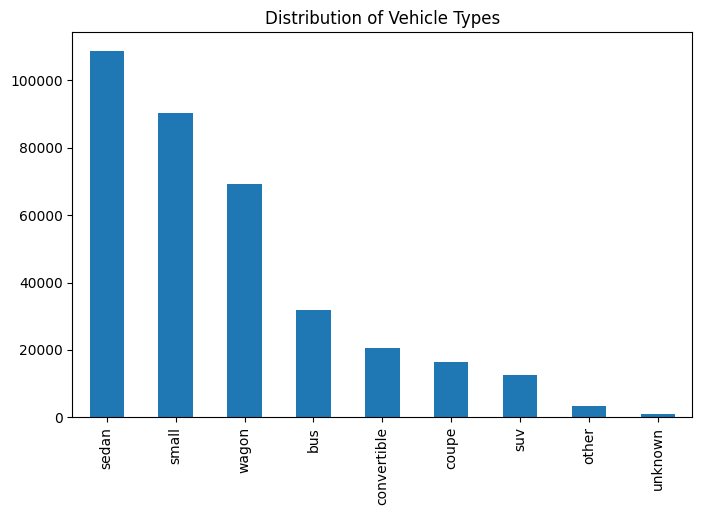

In [26]:
df['vehicle_type'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Distribution of Vehicle Types")


<AxesSubplot:>

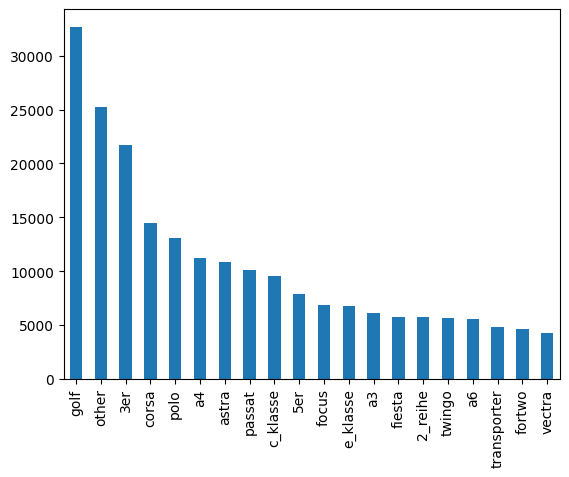

In [27]:
df['model'].value_counts().head(20).plot(kind='bar')


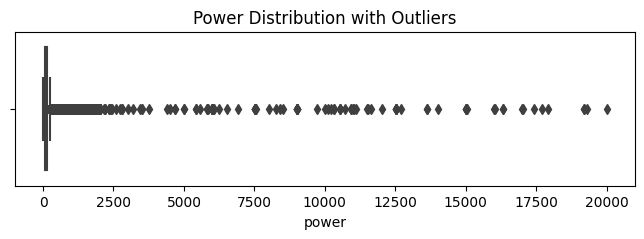

In [28]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['power'])
plt.title("Power Distribution with Outliers")
plt.show()

In [29]:
power_views = df[df['power']>=5000]
power_views.shape

(84, 15)

Text(0, 0.5, 'Count')

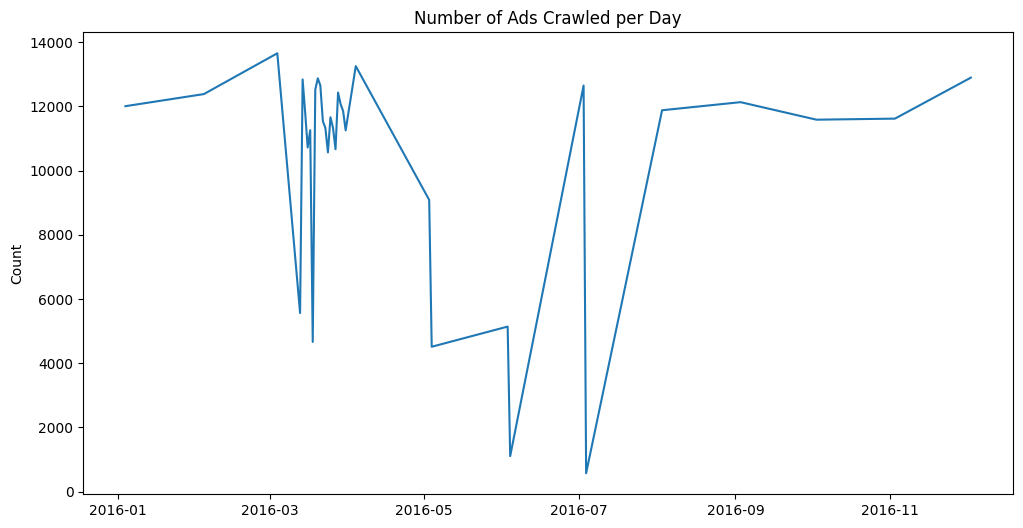

In [30]:
df['date_crawled'].dt.date.value_counts().sort_index().plot(figsize=(12,6))
plt.title("Number of Ads Crawled per Day")
plt.ylabel("Count")


<AxesSubplot:xlabel='gearbox', ylabel='price'>

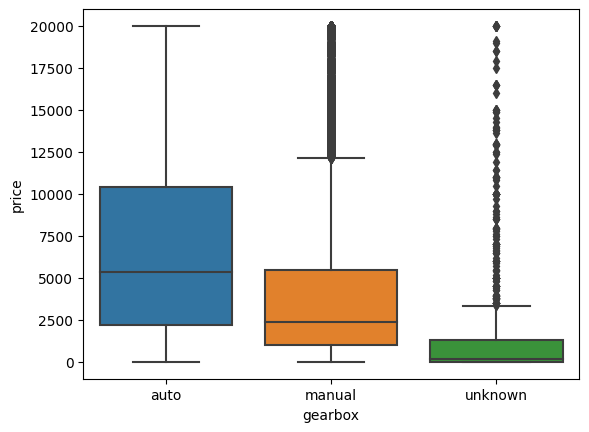

In [31]:
sns.boxplot(x='gearbox', y='price', data=df)


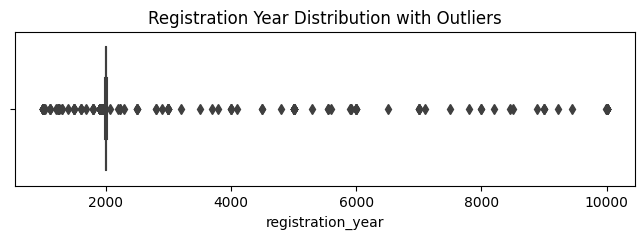

In [32]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['registration_year'])
plt.title("Registration Year Distribution with Outliers")
plt.show()

In [34]:
reg_year = df[(df['registration_year']<1950) | (df['registration_year']>2019) ]
reg_year.shape

(351, 15)

In [35]:
price = df[df['price']<=100]
price.shape

(14342, 15)

In [36]:
# Conditions to DROP
cond_price = df['price'] <= 100
cond_year  = (df['registration_year'] < 1950) | (df['registration_year'] > 2019)
cond_power = df['power'] >= 5000

# Combine conditions
to_drop = cond_price | cond_year | cond_power

# Keep only rows that are NOT in to_drop
df_clean = df[~to_drop].copy()

print("Original shape:", df.shape)
print("After cleaning:", df_clean.shape)

Original shape: (354096, 15)
After cleaning: (339463, 15)


In [37]:
df = df_clean

## Data PreProcessing 

In [38]:
#Upstream to use dates as features
date_cols = ['date_crawled', 'last_seen']


for col in date_cols:
    df[f'{col}_year'] = df[col].dt.year
    df[f'{col}_month'] = df[col].dt.month
    df[f'{col}_dow'] = df[col].dt.dayofweek   # Monday=0, Sunday=6
    df[f'{col}_day'] = df[col].dt.day
    df[f'{col}_hour'] = df[col].dt.hour
    df[f'{col}_minute'] = df[col].dt.minute
    df[f'{col}_second'] = df[col].dt.second

date_cols = ['date_created']
for col in date_cols:
    df[f'{col}_year'] = df[col].dt.year
    df[f'{col}_month'] = df[col].dt.month
    df[f'{col}_dow'] = df[col].dt.dayofweek   # Monday=0, Sunday=6
    df[f'{col}_day'] = df[col].dt.day

# Optionally: difference features
df['ad_lifetime_days'] = (df['last_seen'] - df['date_created']).dt.days


In [39]:
df.head()

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,...,last_seen_dow,last_seen_day,last_seen_hour,last_seen_minute,last_seen_second,date_created_year,date_created_month,date_created_dow,date_created_day,ad_lifetime_days
0,2016-03-24 11:52:00,480,sedan,1993,manual,0,golf,150000,0,petrol,...,0,4,3,16,0,2016,3,3,24,102
1,2016-03-24 10:58:00,18300,coupe,2011,manual,190,a4,125000,5,gasoline,...,0,4,1,46,0,2016,3,3,24,102
2,2016-03-14 12:52:00,9800,suv,2004,auto,163,grand,125000,8,gasoline,...,2,4,12,47,0,2016,3,0,14,51
3,2016-03-17 16:54:00,1500,small,2001,manual,75,golf,150000,6,petrol,...,3,17,17,40,0,2016,3,3,17,0
4,2016-03-31 17:25:00,3600,small,2008,manual,69,fabia,90000,7,gasoline,...,5,4,10,17,0,2016,3,3,31,65


In [40]:
numeric_features = ['power','mileage',
    'registration_year','registration_month','date_crawled_year','date_crawled_month',
    'date_crawled_day', 'date_created_year','date_created_month','date_created_dow',
    'date_created_day','last_seen_year','last_seen_month','last_seen_dow', 'last_seen_day',
    'ad_lifetime_days']

categorical_features = ['brand','model','vehicle_type','gearbox','fuel_type',
    'not_repaired','postal_code' ]



In [41]:
df = df.drop(['date_crawled','date_created','last_seen'],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 339463 entries, 0 to 354095
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   price                339463 non-null  int64   
 1   vehicle_type         339463 non-null  category
 2   registration_year    339463 non-null  int64   
 3   gearbox              339463 non-null  category
 4   power                339463 non-null  int64   
 5   model                339463 non-null  category
 6   mileage              339463 non-null  int64   
 7   registration_month   339463 non-null  int64   
 8   fuel_type            339463 non-null  category
 9   brand                339463 non-null  category
 10  not_repaired         339463 non-null  category
 11  postal_code          339463 non-null  category
 12  date_crawled_year    339463 non-null  int64   
 13  date_crawled_month   339463 non-null  int64   
 14  date_crawled_dow     339463 non-null  int64   
 15  

In [42]:
df.duplicated().sum()

0

## Model training

### Split the source data

In [44]:
# Split: Train (75%) and Test (25%)

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=12345
)

In [45]:
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()
# Encode each categorical column
encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    # Fit on train, transform both train 
    X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))
    X_test_enc[col] = X_test[col].astype(str).map(
    {cls: i for i, cls in enumerate(le.classes_)}
).fillna(-1).astype(int)

    encoders[col] = le  # save encoders if you want to reuse later



In [46]:
def plot_learning_curve(
    estimator,
    X,
    y,
    *,
    cv=3,
    scoring='r2',                 
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1,
    title=None,
    metric_name=None              
):
    sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=42
    )

    # Means and stds
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # Infer metric label if not provided
    if metric_name is None:
        if scoring == 'r2':
            metric_name = 'R²'
        elif scoring in ('neg_root_mean_squared_error', 'neg_mean_squared_error'):
            metric_name = 'RMSE' if scoring == 'neg_root_mean_squared_error' else 'MSE'
        else:
            metric_name = scoring

    # If using a neg_* scorer, flip the sign for interpretability
    if scoring.startswith('neg_'):
        train_mean, val_mean = -train_mean, -val_mean
        train_std, val_std = train_std, val_std  # std stays the same magnitude

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, train_mean, marker='o', label=f'Training {metric_name}')
    plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

    plt.plot(sizes, val_mean, marker='s', label=f'Validation {metric_name}')
    plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

    plt.title(title or f'Learning Curve ({metric_name})')
    plt.xlabel('Training set size')
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return sizes, train_mean, val_mean


### RandomForest Regressor

In [47]:
# --- Pipeline ---
rf_pipe = Pipeline(steps=[
    ('model', RandomForestRegressor(random_state=12345, n_jobs=1))  # keep n_jobs=1 to avoid RAM blow-ups under CV
])

# --- Hyperparam grid (exhaustive) ---
param_grid = {
    'model__n_estimators': [80],   
    'model__max_depth': [10],
    # 'model__min_samples_split': [2, 5, 10, 15, 20],
    # 'model__min_samples_leaf': [1, 2, 4, 6, 8, 10],
    # 'model__max_features': ['sqrt', 'log2', 0.6, 0.8],
    'model__bootstrap': [True],
}

# --- CV-based tuning (RMSE) ---
grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',  # RMSE (negative per sklearn convention)
    n_jobs=2,                                # modest parallelism
    refit=True,                              # refit best model on full training set
    verbose=1
)

start = time.time()
grid.fit(X_train_enc, y_train)               # use your encoded data
train_time = time.time() - start

print("Best CV RMSE:", -grid.best_score_)    # mean CV RMSE of best params
print("Best Params:", grid.best_params_)
print(f"RandomForest model training time: {train_time:.2f} seconds")

rf_best_model = grid.best_estimator_         # fitted on X_train_enc, y_train
start = time.time()
y_train_pred = rf_best_model.predict(X_train_enc)
train_pred_time = time.time() - start
print(f"RF Best Model prediction time: {train_pred_time:.2f} seconds")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best CV RMSE: 1933.3601860619515
Best Params: {'model__bootstrap': True, 'model__max_depth': 10, 'model__n_estimators': 80}
RandomForest model training time: 269.99 seconds
RF Best Model prediction time: 1.43 seconds


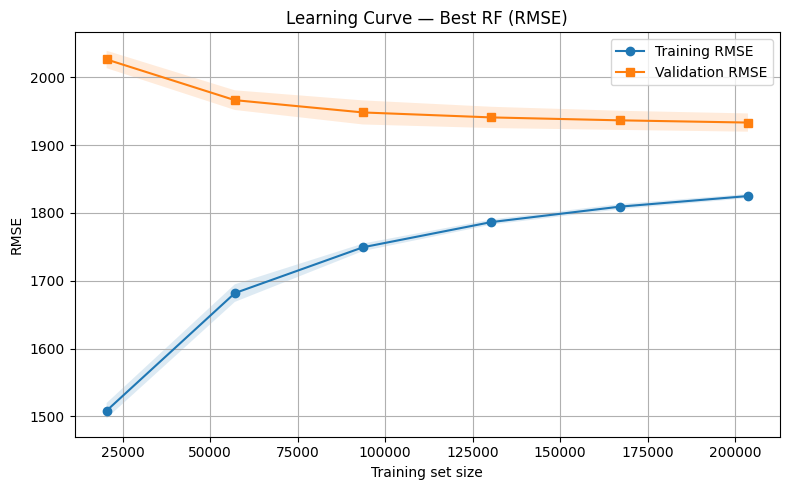

In [48]:
sizes, tr, val = plot_learning_curve(
    estimator=rf_best_model,
    X=X_train_enc,                         
    y=y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    title='Learning Curve — Best RF (RMSE)'
)


### XGBoost

In [49]:
xgb_pipe = Pipeline([('model', XGBRegressor(
    random_state=12345, n_jobs=1, tree_method='hist', objective='reg:squarederror'
))])

xgb_grid = {
    'model__n_estimators': [100, 150], # Saving time
    'model__max_depth': [6,10],
    'model__learning_rate': [0.1, 0.5],
    'model__subsample': [0.8],
    'model__colsample_bytree': [ 1.0],
    'model__reg_lambda': [1.0],
}

xgb_cv = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=2,
    refit=True,
    verbose=1
)

t0 = time.time()
xgb_cv.fit(X_train_enc, y_train)
print("XGB Best CV RMSE:", -xgb_cv.best_score_)
print("XGB Best Params:", xgb_cv.best_params_)
print(f"XGB model training time: {time.time()-t0:.2f}s")
xgb_best = xgb_cv.best_estimator_
start = time.time()
y_train_pred = xgb_best.predict(X_train_enc)
train_pred_time = time.time() - start
print(f"RF Best Model prediction time: {train_pred_time:.2f} seconds")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
XGB Best CV RMSE: 1615.1785649659093
XGB Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__n_estimators': 150, 'model__reg_lambda': 1.0, 'model__subsample': 0.8}
XGB model training time: 20.50s
RF Best Model prediction time: 0.81 seconds


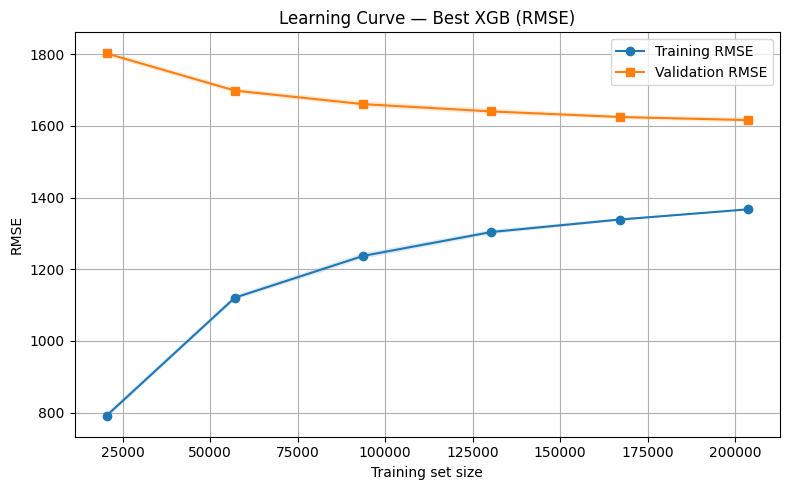

In [50]:
sizes, tr, val = plot_learning_curve(
    estimator=xgb_best,
    X=X_train_enc,                         
    y=y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    title='Learning Curve — Best XGB (RMSE)'
)



### LightGBM

In [51]:
import warnings
warnings.filterwarnings(
    "ignore", 
    category=UserWarning,
    module="lightgbm",
    message="Using categorical_feature in Dataset\."
)



In [52]:
# Ensure categorical_features is the list of categorical column names, dtype='category' in X_train
lgbm_native = Pipeline(steps=[
    ('model', LGBMRegressor(random_state=12345, n_jobs=1, verbose=-1))
])


lgbm_grid_native = {
    'model__n_estimators': [200],     
    'model__num_leaves':  [60],
    'model__learning_rate': [0.1],
    'model__max_depth': [-1],
    'model__subsample': [1.0],
    'model__colsample_bytree': [1.0],
}
lgbm_cv = GridSearchCV(
    lgbm_native, lgbm_grid_native, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=2, refit=True, verbose=1
)
start = time.time()

lgbm_cv.fit(X_train, y_train)
train_time = time.time() - start

print("LGBM Best CV RMSE:", -lgbm_cv.best_score_)
print("LGBM Best Params:", lgbm_cv.best_params_)
print(f"LGBM model training time: {train_time:.2f}s")
lgbm_best = lgbm_cv.best_estimator_
start = time.time()
y_train_pred = lgbm_best.predict(X_train)
train_pred_time = time.time() - start
print(f"LGBM Best Model prediction time: {train_pred_time:.2f} seconds")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
LGBM Best CV RMSE: 1603.7021371404442
LGBM Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': -1, 'model__n_estimators': 200, 'model__num_leaves': 60, 'model__subsample': 1.0}
LGBM model training time: 34.75s
LGBM Best Model prediction time: 5.10 seconds


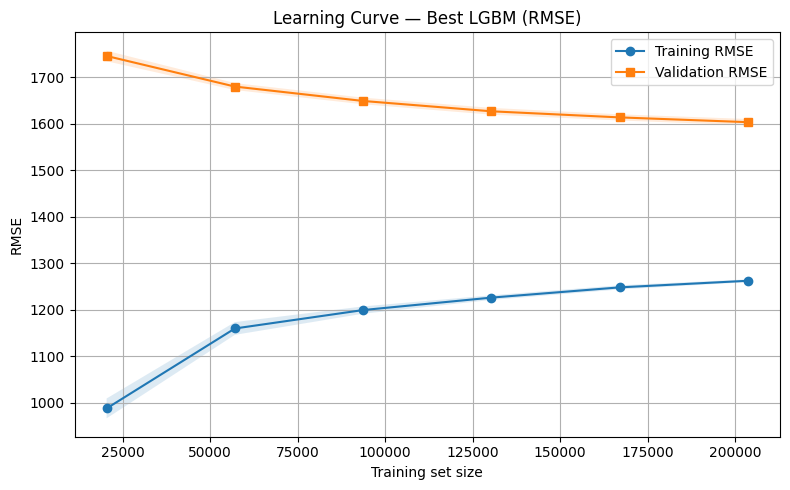

In [53]:
sizes, tr, val = plot_learning_curve(
    estimator=lgbm_best,
    X=X_train,                         
    y=y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    title='Learning Curve — Best LGBM (RMSE)'
)



### CATBoost

In [54]:
# Build categorical feature indices
cat_idx = [X_train.columns.get_loc(c) for c in categorical_features]
cat_native = Pipeline(steps=[
    ('model', CatBoostRegressor(
        random_state=12345,
        loss_function='RMSE',
        verbose=0,
        thread_count=1
    ))
])

cat_grid_native = {
    'model__n_estimators': [150],
    'model__depth': [10],
    'model__learning_rate': [0.1],
    'model__l2_leaf_reg': [1.0],
}

cat_cv = GridSearchCV(
    cat_native, cat_grid_native, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=1, refit=True, verbose=1
)

start = time.time()
cat_cv.fit(X_train, y_train, model__cat_features=cat_idx)
train_time = time.time() - start

print("CatBoost Best CV RMSE:", -cat_cv.best_score_)
print("CatBoost Best Params:", cat_cv.best_params_)
print(f"CatBoost model training time: {train_time:.2f}s")
cat_best = cat_cv.best_estimator_
start = time.time()
y_train_pred = cat_best.predict(X_train)
train_pred_time = time.time() - start
print(f"CatBoost Best Model prediction time: {train_pred_time:.2f} seconds")



Fitting 5 folds for each of 1 candidates, totalling 5 fits
CatBoost Best CV RMSE: 1642.5543924968993
CatBoost Best Params: {'model__depth': 10, 'model__l2_leaf_reg': 1.0, 'model__learning_rate': 0.1, 'model__n_estimators': 150}
CatBoost model training time: 131.36s
CatBoost Best Model prediction time: 0.19 seconds


In [55]:
def plot_learning_curve_cat(
    estimator,
    X,
    y,
    *,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1,
    title=None,
    metric_name=None,
    fit_params=None        # <— NEW
):
    fit_params = fit_params or {}

    sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=42,
        fit_params = fit_params      # <— pass through to .fit()
    )

    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)

    if metric_name is None:
        if scoring == 'r2':
            metric_name = 'R²'
        elif scoring in ('neg_root_mean_squared_error', 'neg_mean_squared_error'):
            metric_name = 'RMSE' if scoring == 'neg_root_mean_squared_error' else 'MSE'
        else:
            metric_name = scoring
    if scoring.startswith('neg_'):
        train_mean, val_mean = -train_mean, -val_mean

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, train_mean, marker='o', label=f'Training {metric_name}')
    plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.plot(sizes, val_mean, marker='s', label=f'Validation {metric_name}')
    plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
    plt.title(title or f'Learning Curve ({metric_name})')
    plt.xlabel('Training set size'); plt.ylabel(metric_name)
    plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()
    return sizes, train_mean, val_mean


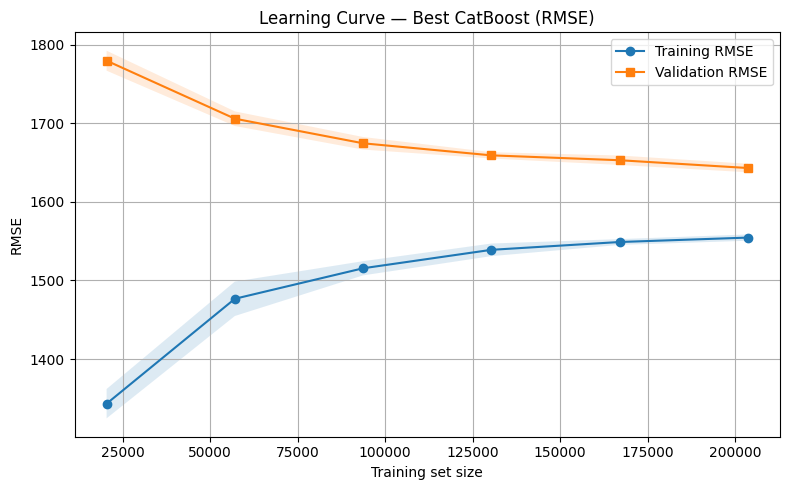

In [56]:
cat_cols = [c for c in X_train.columns if str(X_train[c].dtype) in ("category", "object")]
cat_idx  = [X_train.columns.get_loc(c) for c in cat_cols]

sizes, tr, val = plot_learning_curve_cat(
    estimator=cat_best,                 
    X=X_train,
    y=y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=1,                           # safer with CatBoost to avoid nested parallelism
    title='Learning Curve — Best CatBoost (RMSE)',
    fit_params={'model__cat_features': cat_idx}   # <- pass via fit_params
)

### Model Summaries 
#### 1. LightGBM
- **Best CV RMSE:** 1603   
- **Best Params:** max_depth=-1, num_leaves=60, n_estimators=200, learning_rate=0.1  
- **Training time:** 34.66s 
- **Pred time:** 5.11s  
- **Takeaway:** Best overall tradeoff of speed and accuracy. Slightly edges CatBoost/XGBoost in CV error, with much faster training time but slightly slower prediction. Less altering of data or enhancing model for intake of category dtypes. 

---

#### 2. XGBoost
- **Best CV RMSE:** 1615   
- **Best Params:** max_depth=8, n_estimators=150, learning_rate=0.1, subsample=0.8  
- **Training time:** 20.22  
- **Pred time:** 0.81s
- **Takeaway:** Nearly identical accuracy to LightGBM, but slightly slower training and slightly faster inference. Solid balance.  

---

#### 3. CatBoost
- **Best CV RMSE:** 1642  
- **Best Params:** depth=10, learning_rate=0.1, n_estimators=150  
- **Training time:** 131.36s  
- **Pred time:** 0.19s  
- **Takeaway:** Competitive accuracy, but training and inference times are noticeably higher than LightGBM/XGBoost. Handles categorical features natively with modifications.  

---

#### 4. Random Forest
- **Best CV RMSE:** 2,027    
- **Best Params:** max_depth=10, n_estimators=80, bootstrap=True  
- **Training time:** 264.98s  
- **Pred time:** 1.43s 
- **Takeaway:** Substantially slower with worse accuracy compared to boosting models. Not competitive.  

---
### Summary
- **Boosting models (LightGBM, XGBoost, CatBoost)** clearly outperform both **Random Forest**.  
- **LightGBM** offers the **best accuracy-speed tradeoff**, with the lowest CV RMSE and fast runtime.  
- **XGBoost** is nearly tied in accuracy, with competitive training/inference times.  
- **CatBoost** is attractive for datasets with many categorical features, but slower.  
- **Random Forest** lags behind modern boosting methods both in speed and accuracy.  

If you need **maximum accuracy and efficiency**, go with **LightGBM**.  
If you value **categorical handling and robustness**, choose **CatBoost**.  
If you want a **balance and wide adoption**, use **XGBoost**.  

### I choose **LGBM** for testing due to balance and error handling!

## Model analysis

### LGBM

In [57]:
kf = KFold(n_splits=5, shuffle=True, random_state=12345)
start = time.time()

# --- Cross-validated predictions on test set ---
test_preds = cross_val_predict(
    lgbm_best,          
    X_test,
    y_test,
    cv=kf,
    n_jobs=-1
)
train_time = time.time() - start

# --- Evaluate performance ---
rmse_test = mean_squared_error(y_test, test_preds, squared=False)
r2_test   = r2_score(y_test, test_preds)

print("Test RMSE (CV):", f"{rmse_test:,.2f}")
print("Test R² (CV):",   f"{r2_test:.3f}")

# Optional: Inspect predictions vs actuals
comparison = np.vstack([y_test.values, test_preds]).T[:10]
print("\n[First 10 rows: Actual vs Predicted]")
print(comparison)
print(f"LightGBM test time: {train_time:.2f}s")

Test RMSE (CV): 1,655.64
Test R² (CV): 0.867

[First 10 rows: Actual vs Predicted]
[[ 1750.          1033.96907379]
 [ 6999.          5548.00101859]
 [ 2950.          2467.75253438]
 [  450.           866.58508022]
 [  500.           324.9179704 ]
 [  599.           115.54631404]
 [  550.          1674.88542714]
 [16900.         15615.74407591]
 [  800.          1041.32404849]
 [ 1450.          1720.2974174 ]]
LightGBM test time: 11.16s


### Sanity Check

In [58]:
from sklearn.linear_model import LinearRegression

# --- Scorer: RMSE ---
rmse_scorer = make_scorer(mean_squared_error, squared=False)
start = time.time()
# --- Sanity check models ---
lin_reg = LinearRegression()

# --- Cross-validation scores ---
lin_rmse = -cross_val_score(lin_reg, X_train_enc, y_train, cv=kf,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
train_time = time.time() - start
print("Linear Regression CV RMSE:", f"{lin_rmse.mean():,.2f} ± {lin_rmse.std():.2f}")
print(f"Linear Regression train time: {train_time:.2f}s")

# --- Final test evaluation with plain LinearRegression ---
start = time.time()

lin_reg.fit(X_train_enc, y_train)
test_preds = lin_reg.predict(X_test_enc)
train_time = time.time() - start

test_rmse = mean_squared_error(y_test, test_preds, squared=False)
print("Linear Regression Test RMSE:", f"{test_rmse:,.2f}")
print(f"Linear Regression test time: {train_time:.2f}s")


Linear Regression CV RMSE: 3,213.74 ± 22.60
Linear Regression train time: 0.00s
Linear Regression Test RMSE: 3,219.83
Linear Regression test time: 0.34s


# Model Comparison Summary & Conclusion 

## 1. Linear Regression (Baseline)
- **CV RMSE:** 3,213.74 ± 22.60  
- **Test RMSE:** 3,219.83   
- **Training time:** 0.00s  
- **Test time:** 0.31s  
- **Takeaway:** Extremely fast and interpretable, but error is much higher than tree-based models, confirming that linear assumptions underfit the problem.  
---

## 2. LightGBM
- **Best CV RMSE:** 1,736  
- **Test RMSE:** 1,768  
- **R² (CV):** 0.845  
- **Best Params:** max_depth=-1, num_leaves=60, n_estimators=200, learning_rate=0.1  
- **Training time:** 26s  
- **Test time:** 9.9s  
- **Takeaway:** Best overall tradeoff of speed and accuracy. Slightly edges CatBoost/XGBoost in CV error, with much faster training and prediction.  


---

# Conclusion

Best model for accuracy, training and prediction time is **LGBM** and outperforms the baseline. I beleive this is the best model for the client.